### 基础神经网络分类模型

本章节以MNIST手写数字数据集为例，教大家构建基础的神经网络分类模型。MNIST是经典数据集，含6万训练样本、1万测试样本，每个样本是28x28像素的手写数字图像，目标是将图像分类为0 - 9这10个数字。

#### 模型概述
基础神经网络分类模型包含输入层、隐藏层和输出层。输入层接收图像数据，隐藏层提取和转换特征，输出层给出分类结果。

#### 实现步骤
1. **数据加载与预处理**：加载MNIST训练集和测试集，并归一化处理。
2. **模型构建**：定义网络结构，包括层数、神经元数量和激活函数。
3. **目标定义**：选择损失函数、优化器和评估指标。
4. **模型训练**：用训练数据训练模型，监控损失和准确率。
5. **模型评估**：用测试数据评估模型性能。
6. **模型预测**：用训练好的模型对新数据预测。

下面我们将逐步实现这些步骤，构建一个简单有效的神经网络分类模型。


In [1]:
# 生成一个简单的三层神经网络，要求输入是3维，两个隐层分别为40个神经元，最后输出3个类别
import torch
import torch.nn as nn

class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.fc1 = nn.Linear(3, 40) # 输入层到第一个隐层的全连接层，输入维度为3，输出维度为40
        self.fc2 = nn.Linear(40, 40) # 第一个隐层到第二个隐层的全连接层，输入维度为40，输出维度为40
        self.fc3 = nn.Linear(40, 3) # 第二个隐层到输出层的全连接层，输入维度为40，输出维度为3（对应3个类别）
        self.relu = nn.ReLU() # 定义激活函数为ReLU       

    def forward(self, x): # 前向传播函数，定义了数据如何通过网络流动
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.softmax(self.fc3(x))
        return x

net = Net() # 创建网络实例
print(net) # 打印网络结构

# 输出参数的形状及名称
for name, param in net.named_parameters():
    print(name, param.shape)


Net(
  (fc1): Linear(in_features=3, out_features=40, bias=True)
  (fc2): Linear(in_features=40, out_features=40, bias=True)
  (fc3): Linear(in_features=40, out_features=3, bias=True)
  (relu): ReLU()
)
fc1.weight torch.Size([40, 3])
fc1.bias torch.Size([40])
fc2.weight torch.Size([40, 40])
fc2.bias torch.Size([40])
fc3.weight torch.Size([3, 40])
fc3.bias torch.Size([3])


### 01 加载MNIST数据集

#### 关键知识点探究
- **`transforms.Compose` 和 `normalize` 的作用**：它们的作用是什么呢？
- **`squeeze()` 函数的作用**：这个函数有什么作用呢？


正在加载MNIST数据集...
第一个样本的标签: 1
torch.Size([1, 28, 28])


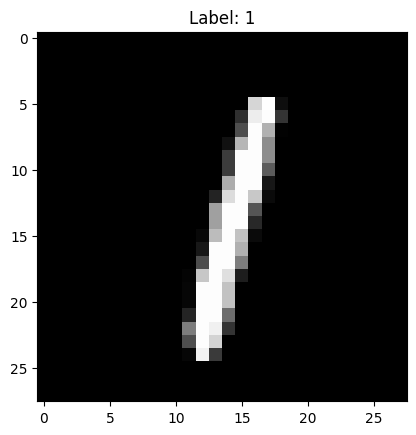

In [2]:
#请帮我读取当前路径下下MNIST文件夹内的数据集，分别为训练集和测试集.
import torch
import torch.nn as nn
import torch.optim as optim # optim是PyTorch中用于优化模型参数的模块，提供了各种优化算法，如SGD、Adam等。
from torch.utils.data import DataLoader # DataLoader是PyTorch中用于加载数据的模块，可以方便地批量加载数据并进行数据增强等操作。
from torchvision import datasets, transforms # torchvision是PyTorch中用于处理图像数据的模块，提供了各种图像处理工具和数据集。transforms是torchvision中的一个子模块，提供了各种图像变换操作，如随机裁剪、随机水平翻转、归一化等。
import matplotlib.pyplot as plt  

# 数据预处理：将图像转换为张量并归一化
transform = transforms.Compose([ # compose函数可以将多个图像变换操作组合在一起，按照顺序依次执行。
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))  # MNIST数据集的均值和标准差，通过先验分析获得，用于将图像数据归一化到0-1之间
])

# 直接读取MNIST数据集（如果不存在会自动下载）
print("正在加载MNIST数据集...")
train_dataset = datasets.MNIST(root='./', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./', train=False, download=True, transform=transform)

#查看数据集的样本，并画图显示
image, label = train_dataset[10085] # 通过索引访问数据集中的第10085个样本，返回图像和对应的标签。
print(f"第一个样本的标签: {label}")
print(image.shape)
plt.imshow(image.squeeze(), cmap='gray') # 使用imshow函数显示图像，squeeze函数用于去除张量中的单维度条目，cmap参数指定使用灰度图显示。
plt.title(f"Label: {label}")
plt.show()


In [3]:
# 创建数据加载器
# 以下代码创建数据加载器，`DataLoader` 是 PyTorch 中用于批量加载数据的工具
# `train_loader` 用于加载训练数据，`batch_size=64` 表示每次加载 64 个样本，`shuffle=True` 表示每个 epoch 开始前打乱数据顺序
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
# `test_loader` 用于加载测试数据，`batch_size=64` 表示每次加载 64 个样本，`shuffle=False` 表示不打乱数据顺序
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)


print(f"训练集大小: {len(train_dataset)}")
print(f"测试集大小: {len(test_dataset)}")


训练集大小: 60000
测试集大小: 10000


### 02 模型定义与损失函数
- 定义一个简单的神经网络模型，包含三层全连接层，激活函数为ReLU
- 模型的输入层为28x28的图像，输出层为10个类别
- 损失函数为交叉熵损失函数


In [4]:
# 定义简单的神经网络
import torch
import torch.nn as nn
import torch.optim as optim

class SimpleNet(nn.Module):
    def __init__(self):
        super(SimpleNet, self).__init__()
        self.flatten = nn.Flatten()  # 将28x28图像展平为784维向量，每个图像的像素值被转换为一个一维向量，便于输入到全连接层中
        self.fc1 = nn.Linear(28*28, 128) # 输入层到第一个隐层的全连接层，输入维度为28*28=784，输出维度为128
        self.fc2 = nn.Linear(128, 64) # 第一个隐层到第二个隐层的全连接层，输入维度为128，输出维度为64
        self.fc3 = nn.Linear(64, 10) # 第二个隐层到输出层的全连接层，输入维度为64，输出维度为10，对应10个类别
        self.relu = nn.ReLU() # ReLU激活函数用于引入非线性，使模型能够学习更复杂的函数关系
        self.dropout = nn.Dropout(p=0.3) # Dropout用于训练时随机失活部分神经元，减少过拟合, p为失活概率
        self.softmax = nn.Softmax(dim=1) # Softmax用于输出层将输出转换为概率分布，dim=1表示对每一行进行归一化
        self.loss_fn = nn.CrossEntropyLoss() # 交叉熵损失函数用于计算模型预测与真实标签之间的差异
        self.optimizer = optim.Adam(self.parameters(), lr=0.001) # Adam优化器用于更新模型参数，lr为学习率
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu") # 检查是否有可用的GPU，如果有则使用GPU，否则使用CPU        
        
    # 前向传播函数，定义了数据如何通过网络流动
    def forward(self, x):
        # 完成网络结构定义
        x = self.flatten(x) # 将输入图像展平为一维向量
        x = self.relu(self.fc1(x)) # 通过第一个全连接层并
        #应用ReLU激活函数
        x = self.dropout(x) # 应用Dropout进行正则化
        x = self.relu(self.fc2(x)) # 通过第二个全连接层并应用ReLU激活函数
        x = self.dropout(x) # 再次应用Dropout进行正则化
        x = self.softmax(self.fc3(x)) # 通过输出层并应用Softmax函数将输出转换为概率分布
        return x
# 创建模型
model = SimpleNet()
x = torch.randn(1, 1, 28, 28) # 创建一个随机输入张量，形状为(1, 1, 28, 28)，表示一个批次中有1个样本，每个样本是一个单通道的28x28图像。
output = model(x)
print(output.shape)

torch.Size([1, 10])


<details>
<summary>模型结构定义参考</summary>

```python
    def forward(self, x):
        x = self.flatten(x)
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.relu(self.fc2(x))
        x = self.dropout(x)
        x = self.softmax(self.fc3(x))
        return x
```
</details>

### 训练模型及评估
- 训练模型5个epoch，每个epoch打印一次损失值和准确率
- 评估模型在测试集上的准确率

In [5]:
num_epochs = 5
device = model.device # 使用GPU加速训练（如有）

model = model.to(device) # 将模型移动到指定设备上
criterion = model.loss_fn # 交叉熵损失函数
optimizer = model.optimizer # Adam优化器

# 训练模型
for epoch in range(num_epochs):
    model.train() # 将模型设置为训练模式，启用dropout和batch normalization等训练特定的行为
    epoch_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader: # 遍历训练数据加载器，获取每个批次的图像和标签
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad() # 清除之前的梯度信息，避免梯度累积
        outputs = model(images) # 前向传播，计算模型的输出
        loss = criterion(outputs, labels) # 计算损失值，criterion是定义的损失函数，这里使用交叉熵损失
        loss.backward() # 反向传播，计算梯度
        optimizer.step() # 更新模型参数，根据计算得到的梯度进行优化

        epoch_loss += loss.item() * images.size(0) # 累加当前批次的损失值，乘以批次大小以获得总损失值
        _, predicted = torch.max(outputs, 1) # torch.max返回最大值和对应的索引，_表示最大值，predicted表示索引，即预测的类别, 1表示在最后一个维度上取最大值
        total += labels.size(0) # 累加标签数量
        correct += (predicted == labels).sum().item() # 累加预测正确的数量，比较预测结果和真实标签，得到一个布尔值张量，再求和得到正确的数量

    avg_loss = epoch_loss / total
    train_acc = 100 * correct / total
    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.4f}, Train Acc: {train_acc:.2f}%") # 打印当前epoch的损失值和训练准确率

# 保存模型
torch.save(model.state_dict(), 'mnist_bp.pth')

# 评估模型
model.eval() # 将模型设置为评估模式，禁用dropout和batch normalization等训练特定的行为
with torch.no_grad(): # 禁用梯度计算，以节省内存和计算资源
    correct = 0
    total = 0
    for images, labels in test_loader: # 遍历测试数据加载器，获取每个批次的图像和标签
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images) # 前向传播，计算模型的输出
        _, predicted = torch.max(outputs, 1) # 获取模型预测结果的最大值及其索引
        total += labels.size(0) # 累计样本总数
        correct += (predicted == labels).sum().item() # 累计预测正确的样本数

    print(f"测试准确率: {100 * correct / total:.2f}%") # 打印模型在测试集上的准确率

Epoch [1/5], Loss: 1.6254, Train Acc: 84.83%
Epoch [2/5], Loss: 1.5438, Train Acc: 92.11%
Epoch [3/5], Loss: 1.5297, Train Acc: 93.34%
Epoch [4/5], Loss: 1.5225, Train Acc: 93.97%
Epoch [5/5], Loss: 1.5174, Train Acc: 94.49%
测试准确率: 96.01%


<details>
<summary>参考代码</summary>

```python
# 加载模型
num_epochs = 5
device = model.device # 使用GPU加速训练（如有）

model = model.to(device) # 将模型移动到指定设备上
criterion = model.loss_fn # 交叉熵损失函数
optimizer = model.optimizer # Adam优化器

# 训练模型
for epoch in range(num_epochs):
    model.train() # 将模型设置为训练模式，启用dropout和batch normalization等训练特定的行为
    epoch_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader: # 遍历训练数据加载器，获取每个批次的图像和标签
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad() # 清除之前的梯度信息，避免梯度累积
        outputs = model(images) # 前向传播，计算模型的输出
        loss = criterion(outputs, labels) # 计算损失值，criterion是定义的损失函数，这里使用交叉熵损失
        loss.backward() # 反向传播，计算梯度
        optimizer.step() # 更新模型参数，根据计算得到的梯度进行优化

        epoch_loss += loss.item() * images.size(0) # 累加当前批次的损失值，乘以批次大小以获得总损失值
        _, predicted = torch.max(outputs, 1) # torch.max返回最大值和对应的索引，_表示最大值，predicted表示索引，即预测的类别, 1表示在最后一个维度上取最大值
        total += labels.size(0) # 累加标签数量
        correct += (predicted == labels).sum().item() # 累加预测正确的数量，比较预测结果和真实标签，得到一个布尔值张量，再求和得到正确的数量

    avg_loss = epoch_loss / total
    train_acc = 100 * correct / total
    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.4f}, Train Acc: {train_acc:.2f}%") # 打印当前epoch的损失值和训练准确率

# 保存模型
torch.save(model.state_dict(), 'mnist_bp.pth')

# 评估模型
model.eval() # 将模型设置为评估模式，禁用dropout和batch normalization等训练特定的行为
with torch.no_grad(): # 禁用梯度计算，以节省内存和计算资源
    correct = 0
    total = 0
    for images, labels in test_loader: # 遍历测试数据加载器，获取每个批次的图像和标签
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images) # 前向传播，计算模型的输出
        _, predicted = torch.max(outputs, 1) # 获取模型预测结果的最大值及其索引
        total += labels.size(0) # 累计样本总数
        correct += (predicted == labels).sum().item() # 累计预测正确的样本数

    print(f"测试准确率: {100 * correct / total:.2f}%") # 打印模型在测试集上的准确率
```


### 测试testpic中的5张照片，输出模型的预测结果

In [6]:
# 需要你补齐的代码

from PIL import Image
import os
import torch

# Load pictures from the test directory, preprocess them, and prepare for prediction
test_tensors = []
test_labels = []  
test_dir = './testpic'  

for filename in sorted(os.listdir(test_dir)):
    if filename.lower().endswith('.png'):
        image_path = os.path.join(test_dir, filename)
        image = Image.open(image_path).convert('L').resize((28, 28))  # 转灰度并缩放到MNIST尺寸
        image_tensor = transform(image)  # 与训练集一致的预处理: ToTensor + Normalize
        test_tensors.append(image_tensor)
        test_labels.append(int(filename.split('_')[0]))

# 堆叠为 [N, 1, 28, 28]
test_images = torch.stack(test_tensors)

# 使用模型进行预测
device = next(model.parameters()).device
test_images = test_images.to(device)
model.eval()  # 设置模型为评估模式
with torch.no_grad():  # 关闭梯度计算，节省内存
    outputs = model(test_images)  # 前向传播，计算模型输出
    _, predicted = torch.max(outputs.data, 1)  # 获取预测类别
    predicted = predicted.to(device)  # 确保预测结果在同一设备上

# 打印预测结果
for i in range(len(test_images)):
    print(f"图片 {i+1} 的预测标签: {predicted[i].item()}，真实标签: {test_labels[i]}")

# 计算精度
correct = (predicted == torch.tensor(test_labels).to(device)).sum().item()
accuracy = 100 * correct / len(test_labels)
print(f"测试精度: {accuracy:.2f}%")

图片 1 的预测标签: 1，真实标签: 1
图片 2 的预测标签: 5，真实标签: 1
图片 3 的预测标签: 1，真实标签: 1
图片 4 的预测标签: 2，真实标签: 2
图片 5 的预测标签: 2，真实标签: 2
测试精度: 80.00%


<details>
<summary>参考代码</summary>

```python
from PIL import Image
import os
import torch

# 加载测试图片
test_tensors = []
test_labels = []  # 假设文件名中的前缀数字是标签，如 7_xxx.png
test_dir = './testpic'  # 测试图片所在目录

for filename in sorted(os.listdir(test_dir)):
    if filename.lower().endswith('.png'):
        image_path = os.path.join(test_dir, filename)
        image = Image.open(image_path).convert('L').resize((28, 28))  # 转灰度并缩放到MNIST尺寸
        image_tensor = transform(image)  # 与训练集一致的预处理: ToTensor + Normalize
        test_tensors.append(image_tensor)
        test_labels.append(int(filename.split('_')[0]))

# 堆叠为 [N, 1, 28, 28]
test_images = torch.stack(test_tensors)

# 使用模型进行预测
device = next(model.parameters()).device
test_images = test_images.to(device)
model.eval()  # 设置模型为评估模式
with torch.no_grad():  # 关闭梯度计算，节省内存
    outputs = model(test_images)  # 前向传播，计算模型输出
    _, predicted = torch.max(outputs.data, 1)  # 获取预测类别
    predicted = predicted.to(device)  # 确保预测结果在同一设备上

# 打印预测结果
for i in range(len(test_images)):
    print(f"图片 {i+1} 的预测标签: {predicted[i].item()}，真实标签: {test_labels[i]}")

# 计算精度
correct = (predicted == torch.tensor(test_labels).to(device)).sum().item()
accuracy = 100 * correct / len(test_labels)
print(f"测试精度: {accuracy:.2f}%")
```
